# 심장질환
### 데이터 불러오기

In [75]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv('train.csv')
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


### 데이터 전처리

- 1 : 심장 질환 있음, 0 : 심장 질환 없음
- 노인 : 65세 이상

In [77]:
df['Heart Disease'] = df['Heart Disease'].astype(str).str.strip()
df['Heart Disease'] = df['Heart Disease'].map({'Presence' : 1, 'Absence' : 0})
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


In [78]:
df['old'] = df['Age'] >= 65
df.head()

# df.value_counts(df['old'] == True)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,old
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1,False
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0,False
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0,False
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0,False
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1,False


### id 빼기

In [79]:
df = df.drop('id', axis = 1)
df.head(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,old
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1,False
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0,False
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0,False
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0,False
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1,False


### 65세 이상 데이터만으로 DataFrame 만들기

In [80]:
df_old = df[df['Age'] >= 65]
df_old.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,old
18,65,0,4,140,197,0,0,161,0,2.2,2,1,3,1,True
21,65,1,3,120,226,0,0,145,1,0.0,2,0,3,1,True
27,66,1,4,110,234,0,2,122,0,0.0,1,0,7,0,True
38,71,1,4,100,229,0,2,154,0,0.0,1,1,7,1,True
61,65,1,4,118,282,0,2,165,1,1.2,2,0,7,1,True


### 심장 질환 발병 현황

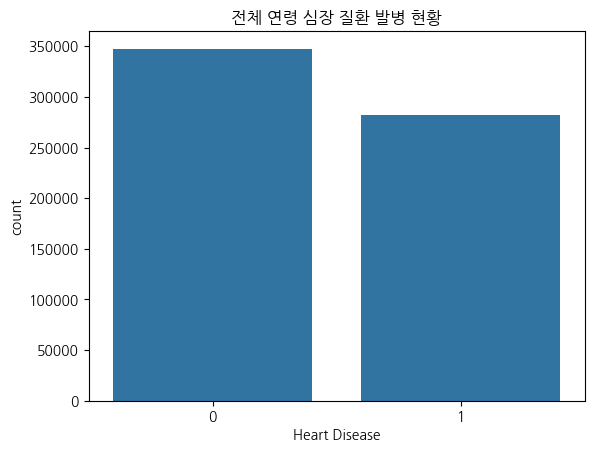

In [81]:
import koreanize_matplotlib

sns.countplot(x = 'Heart Disease', data = df)
plt.title('전체 연령 심장 질환 발병 현황')
plt.show()

### 65세 이상 심장 질환 발병 현황

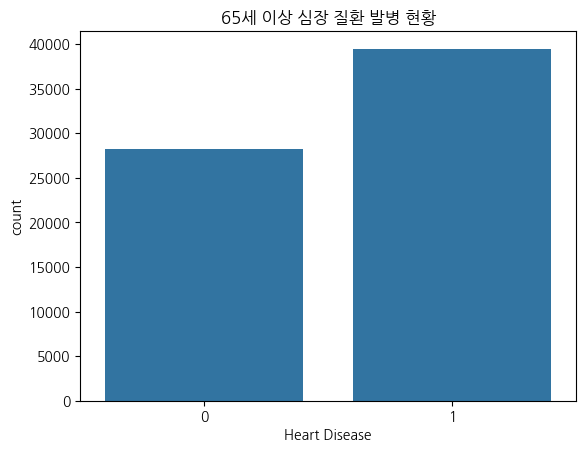

In [82]:
sns.countplot(x = 'Heart Disease', data = df_old)

plt.title('65세 이상 심장 질환 발병 현황')
plt.show()

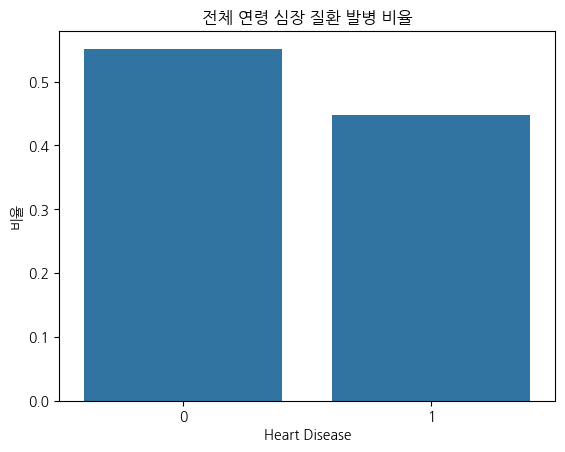

In [84]:
total_ratio = df['Heart Disease'].value_counts(normalize=True)

sns.barplot(x=total_ratio.index, y=total_ratio.values)
plt.title('전체 연령 심장 질환 발병 비율')
plt.ylabel('비율')
plt.show()

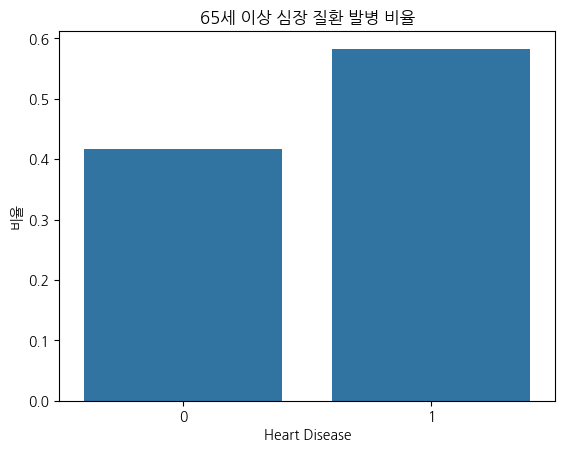

In [85]:
total_ratio = df_old['Heart Disease'].value_counts(normalize=True)

sns.barplot(x=total_ratio.index, y=total_ratio.values)
plt.title('65세 이상 심장 질환 발병 비율')
plt.ylabel('비율')
plt.show()

In [86]:
X = df_old.drop(['Heart Disease'], axis = 1)
y = df_old['Heart Disease']

### DecisionTree (의사결정트리)

In [87]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

dt_clf = DecisionTreeClassifier()
train_data = X
train_label = y

X_train, X_test, y_train, y_test = train_test_split(train_data, train_label, test_size = 0.2, random_state = 121)

dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
dt_acc = accuracy_score(y_test, pred)
dt_pre = precision_score(y_test, pred)
dt_rec = recall_score(y_test, pred)
dt_f1 = f1_score(y_test, pred)

print('정확도 :', accuracy_score(y_test, pred))
print('정밀도 :', precision_score(y_test, pred))
print('재현율 :', recall_score(y_test, pred))
print('F1 - Score :', f1_score(y_test, pred))

정확도 : 0.809242580835671
정밀도 : 0.8328530259365994
재현율 : 0.841712042547803
F1 - Score : 0.8372591006423983


In [88]:
from sklearn.metrics import roc_auc_score

pred_proba = dt_clf.predict_proba(X_test)[:,1]
dt_auc = roc_auc_score(y_test, pred_proba)

print("ROC-AUC :", dt_auc)

ROC-AUC : 0.802782025876486


In [89]:
# 특성 중요도
import pandas as pd

importance = dt_clf.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                    feature  importance
12                 Thallium    0.336895
2           Chest pain type    0.131210
7                    Max HR    0.126630
4               Cholesterol    0.102596
3                        BP    0.064752
9             ST depression    0.063537
0                       Age    0.044210
11  Number of vessels fluro    0.040305
10              Slope of ST    0.029084
8           Exercise angina    0.024670
1                       Sex    0.017007
6               EKG results    0.013289
5              FBS over 120    0.005816
13                      old    0.000000


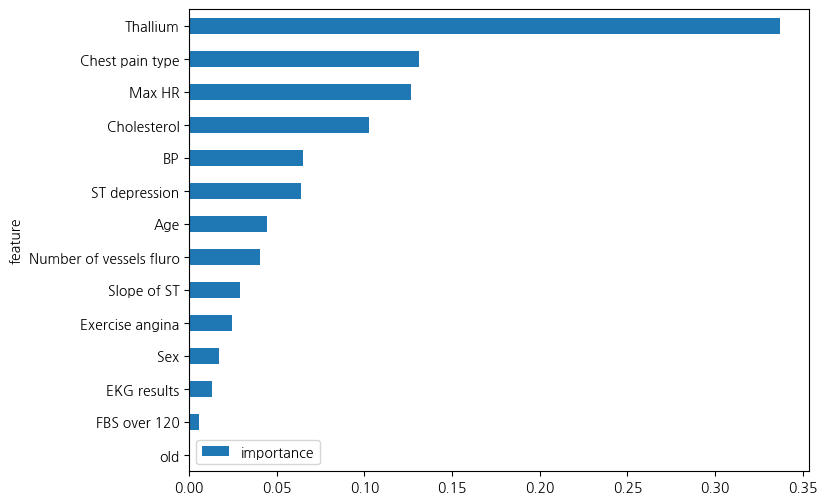

In [90]:
# 특성 중요도 시각화
import matplotlib.pyplot as plt

feature_importance.sort_values(by='importance').plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(8,6)
)

plt.show()

### 데이터 스케일링 (표준화)

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 로지스틱 회귀

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = LogisticRegression(max_iter = 1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
model_acc = accuracy_score(y_test, y_pred)
model_pre = precision_score(y_test, y_pred)
model_rec = recall_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred)

print('정확도 :', accuracy_score(y_test, y_pred))
print('정밀도 :', precision_score(y_test, y_pred))
print('재현율 :', recall_score(y_test, y_pred))
print('F1 - Score', f1_score(y_test, y_pred))

정확도 : 0.8720655544072051
정밀도 : 0.8889449772841999
재현율 : 0.8919842978346207
F1 - Score 0.8904620441185765


In [93]:
from sklearn.metrics import roc_auc_score

lr_prob = model.predict_proba(X_test_scaled)[:,1]
model_auc = roc_auc_score(y_test, pred_proba)

print("ROC-AUC :", model_auc)

ROC-AUC : 0.802782025876486


### Random Forest

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_pre = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print('정확도 :', accuracy_score(y_test, rf_pred))
print('정밀도 :', precision_score(y_test, rf_pred))
print('재현율 :', recall_score(y_test, rf_pred))
print('F1 - Score', f1_score(y_test, rf_pred))

정확도 : 0.8697032334268419
정밀도 : 0.8828671328671329
재현율 : 0.8952766873496264
F1 - Score 0.8890286073561773


In [96]:
from sklearn.metrics import roc_auc_score

pred_proba = rf_model.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, pred_proba)

print("ROC-AUC :", rf_auc)

ROC-AUC : 0.9385752611070399


In [97]:
# 특성 중요도
import pandas as pd

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                    feature  importance
12                 Thallium    0.183344
7                    Max HR    0.143287
2           Chest pain type    0.134853
4               Cholesterol    0.090687
9             ST depression    0.085665
11  Number of vessels fluro    0.081724
3                        BP    0.066532
8           Exercise angina    0.057431
10              Slope of ST    0.055402
0                       Age    0.045273
1                       Sex    0.034968
6               EKG results    0.014649
5              FBS over 120    0.006184
13                      old    0.000000


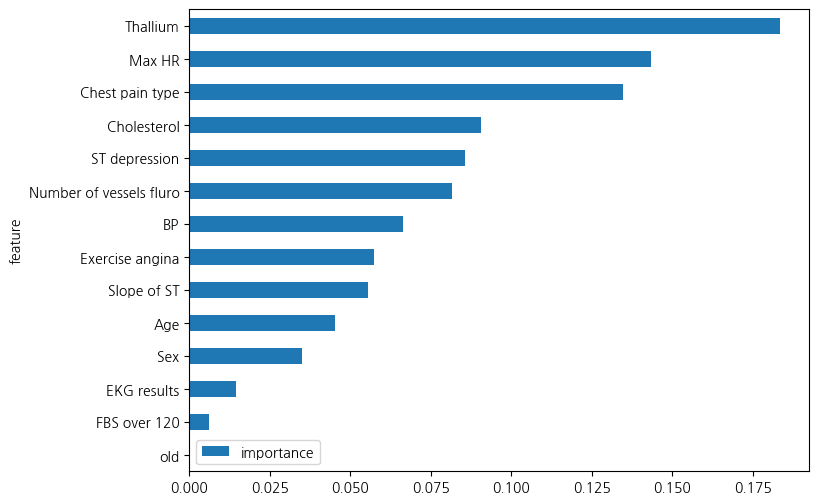

In [98]:
# 특성 중요도 시각화
import matplotlib.pyplot as plt

feature_importance.sort_values(by='importance').plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(8,6)
)

plt.show()

### Gradient Boosting

In [99]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)
gb_pre = precision_score(y_test, gb_pred)
gb_rec = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)

print('정확도 :', accuracy_score(y_test, gb_pred))
print('정밀도 :', precision_score(y_test, gb_pred))
print('재현율 :', recall_score(y_test, gb_pred))
print('F1 - Score', f1_score(y_test, gb_pred))

정확도 : 0.8753875682858409
정밀도 : 0.8897677338355304
재현율 : 0.8974294035709763
F1 - Score 0.8935821460093305


In [100]:
from sklearn.metrics import roc_auc_score

pred_proba = gb_model.predict_proba(X_test)[:,1]
gb_auc = roc_auc_score(y_test, pred_proba)

print("ROC-AUC :", gb_auc)

ROC-AUC : 0.9467140921933176


In [101]:
# 특성 중요도
import pandas as pd

importance = gb_model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                    feature  importance
12                 Thallium    0.457415
2           Chest pain type    0.190099
7                    Max HR    0.088888
11  Number of vessels fluro    0.077282
8           Exercise angina    0.060918
10              Slope of ST    0.051173
9             ST depression    0.042806
1                       Sex    0.025296
6               EKG results    0.003554
4               Cholesterol    0.001327
0                       Age    0.000904
3                        BP    0.000338
5              FBS over 120    0.000000
13                      old    0.000000


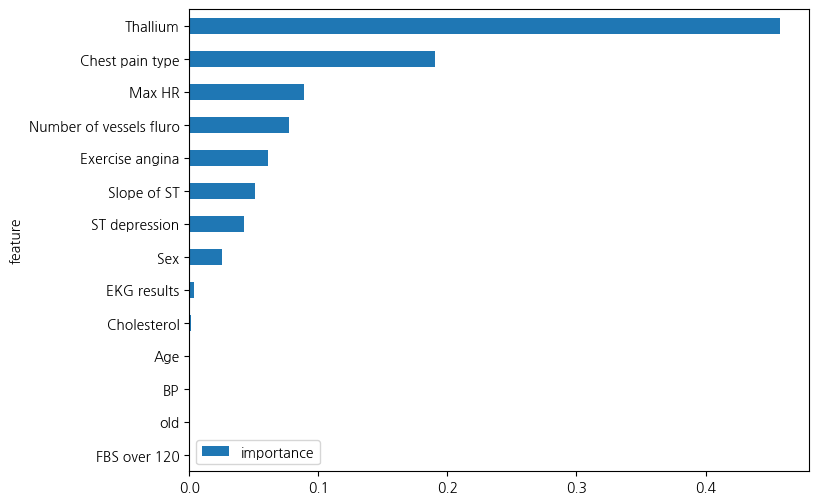

In [102]:
# 특성 중요도 시각화
import matplotlib.pyplot as plt

feature_importance.sort_values(by='importance').plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(8,6)
)

plt.show()

### XGBoost

In [103]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_pre = precision_score(y_test, xgb_pred)
xgb_rec = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print('정확도 :', accuracy_score(y_test, xgb_pred))
print('정밀도 :', precision_score(y_test, xgb_pred))
print('재현율 :', recall_score(y_test, xgb_pred))
print('F1 - Score', f1_score(y_test, xgb_pred))

정확도 : 0.8742064077956593
정밀도 : 0.8896438907763936
재현율 : 0.8952766873496264
F1 - Score 0.8924514011613229


c:\Users\KDS21\anaconda3\envs\bigdata\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:35:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [104]:
from sklearn.metrics import roc_auc_score

pred_proba = xgb_model.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, pred_proba)

print("ROC-AUC :", xgb_auc)

ROC-AUC : 0.9461300323269457


In [105]:
# 특성 중요도
import pandas as pd

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                    feature  importance
12                 Thallium    0.656320
2           Chest pain type    0.137798
11  Number of vessels fluro    0.043316
8           Exercise angina    0.042390
10              Slope of ST    0.038637
1                       Sex    0.021627
7                    Max HR    0.020434
9             ST depression    0.015552
6               EKG results    0.010864
4               Cholesterol    0.003617
0                       Age    0.003325
5              FBS over 120    0.003207
3                        BP    0.002913
13                      old    0.000000


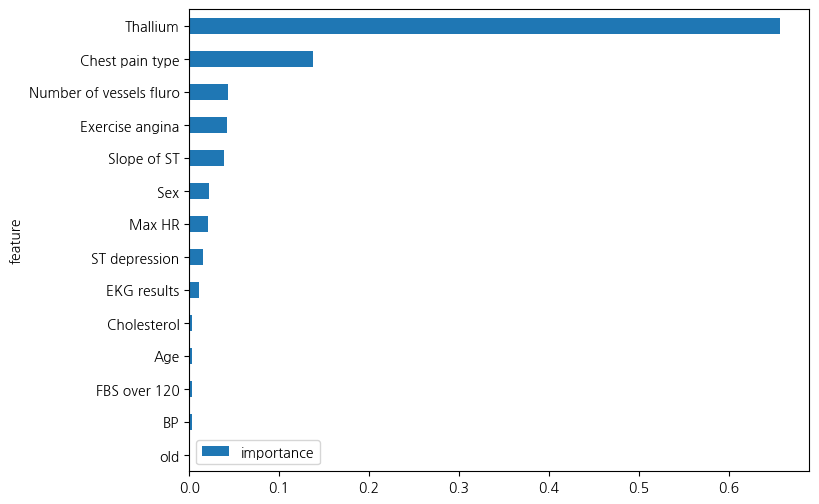

In [106]:
# 특성 중요도 시각화
import matplotlib.pyplot as plt

feature_importance.sort_values(by='importance').plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(8,6)
)

plt.show()

### LightGBM

In [107]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)
lgbm_acc = accuracy_score(y_test, lgbm_pred)
lgbm_pre = precision_score(y_test, lgbm_pred)
lgbm_rec = recall_score(y_test, lgbm_pred)
lgbm_f1 = f1_score(y_test, lgbm_pred)

print('정확도 :', accuracy_score(y_test, lgbm_pred))
print('정밀도 :', precision_score(y_test, lgbm_pred))
print('재현율 :', recall_score(y_test, lgbm_pred))
print('F1 - Score', f1_score(y_test, lgbm_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 31583, number of negative: 22601
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 353
[LightGBM] [Info] Number of data points in the train set: 54184, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.582884 -> initscore=0.334625
[LightGBM] [Info] Start training from score 0.334625
정확도 : 0.8745016979182046
정밀도 : 0.8893077019726097
재현율 : 0.8962897302773205
F1 - Score 0.8927850655903128


In [108]:
from sklearn.metrics import roc_auc_score

pred_proba = lgbm_model.predict_proba(X_test)[:,1]
lgbm_auc = roc_auc_score(y_test, pred_proba)

print("ROC-AUC :", lgbm_auc)

ROC-AUC : 0.9460290911802074


In [109]:
# 특성 중요도
import pandas as pd

importance = lgbm_model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                    feature  importance
7                    Max HR         780
4               Cholesterol         382
9             ST depression         329
3                        BP         247
11  Number of vessels fluro         232
2           Chest pain type         195
0                       Age         177
1                       Sex         151
10              Slope of ST         150
8           Exercise angina         142
6               EKG results          99
12                 Thallium          96
5              FBS over 120          20
13                      old           0


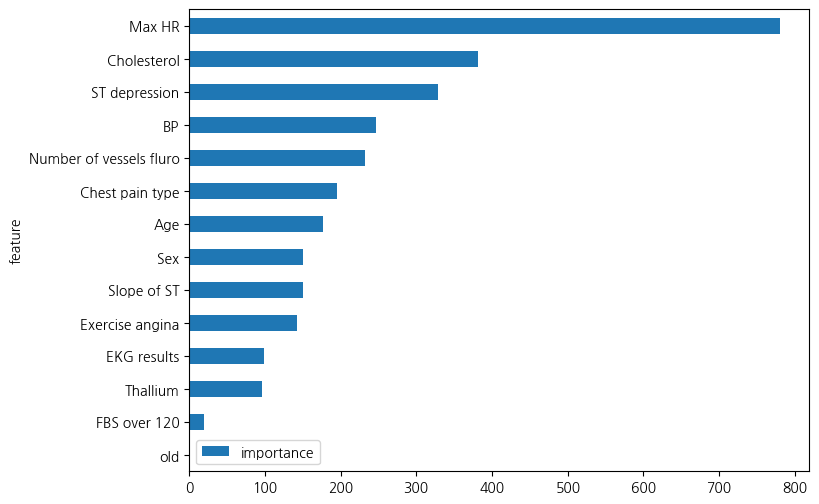

In [110]:
# 특성 중요도 시각화
import matplotlib.pyplot as plt

feature_importance.sort_values(by='importance').plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(8,6)
)

plt.show()

### 모델 성능 비교

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "Decision Tree" : DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append([name, acc, pre, rec, f1, auc])
    
result_df = pd.DataFrame(results, columns=[
    "Model","Accuracy","Precision","Recall","F1 Score","ROC-AUC"
])

print(result_df)

c:\Users\KDS21\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\KDS21\anaconda3\envs\bigdata\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:35:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 31583, number of negative: 22601
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 353
[LightGBM] [Info] Number of data points in the train set: 54184, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.582884 -> initscore=0.334625
[LightGBM] [Info] Start training from score 0.334625
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0        Decision Tree  0.811014   0.835618  0.841332  0.838465  0.804982
1  Logistic Regression  0.872139   0.888861  0.892238  0.890546  0.943952
2        Random Forest  0.868670   0.884393  0.891225  0.887796  0.938532
3    Gradient Boosting  0.875388   0.889768  0.897429  0.893582  0.94

### Gradient Boosting 모델 confusin_matrix

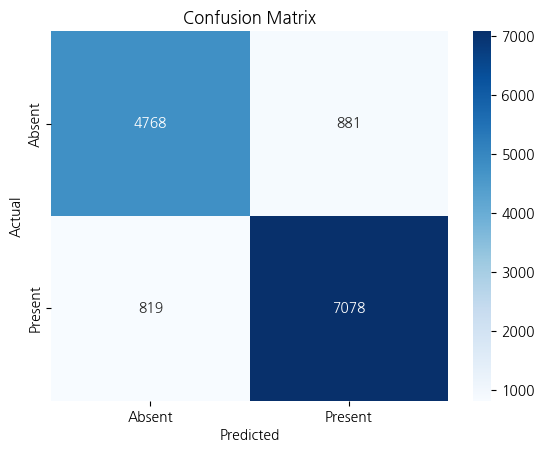

In [112]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Absent','Present'],
            yticklabels=['Absent','Present'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Gradient Boosting 모델 roc_curve

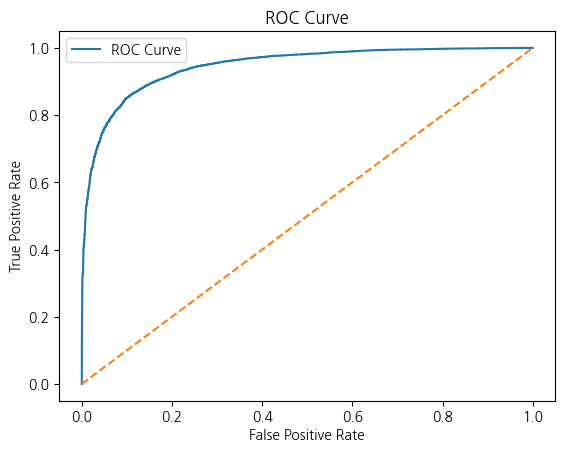

In [113]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### Gradient Boosting 모델 특성 중요도

In [114]:
import pandas as pd
import koreanize_matplotlib

importance = gb_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                    Feature  Importance
12                 Thallium    0.457415
2           Chest pain type    0.190099
7                    Max HR    0.088888
11  Number of vessels fluro    0.077282
8           Exercise angina    0.060918
10              Slope of ST    0.051173
9             ST depression    0.042806
1                       Sex    0.025296
6               EKG results    0.003554
4               Cholesterol    0.001327
0                       Age    0.000904
3                        BP    0.000338
5              FBS over 120    0.000000
13                      old    0.000000


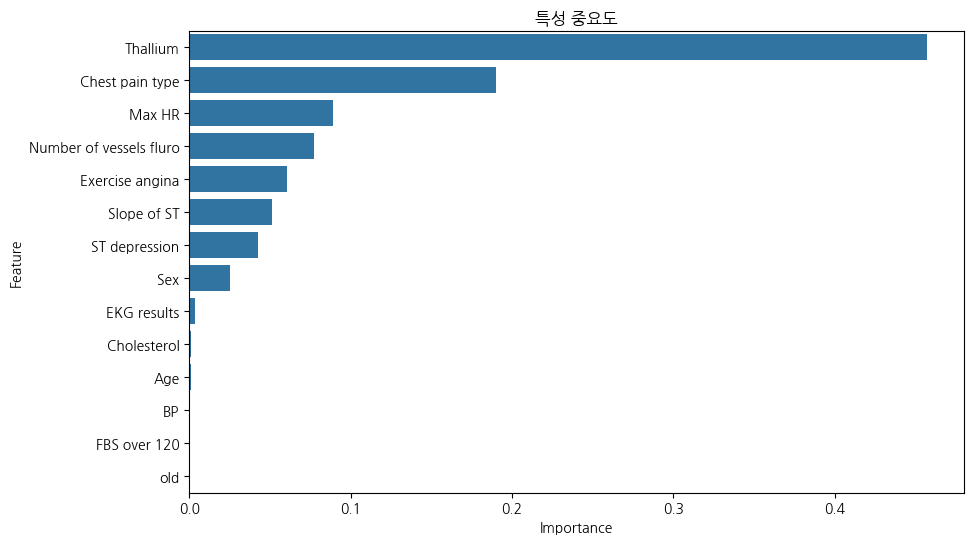

In [115]:
plt.figure(figsize=(10,6))

sns.barplot(x='Importance', y='Feature', data=feature_importance)

plt.title("특성 중요도")
plt.show()

### 나이와 심장 질환

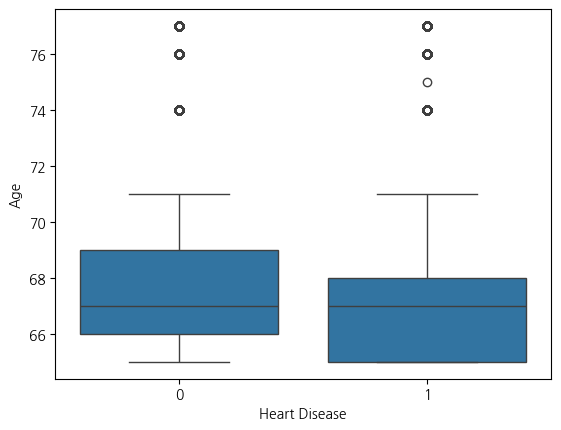

In [116]:
sns.boxplot(x='Heart Disease', y='Age', data=df_old)
plt.show()

### 흉통 분석

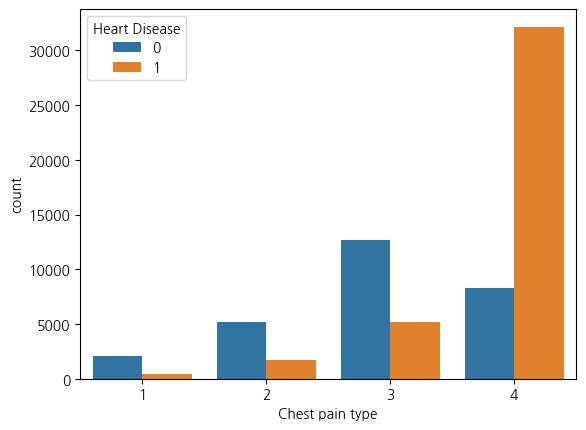

In [117]:
sns.countplot(x="Chest pain type", hue="Heart Disease", data=df_old)
plt.show()

### Gradient Boosting 하이퍼파라미터 튜닝 (GridSearchCV)

In [118]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb_clf = GradientBoostingClassifier(random_state=42)

params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    gb_clf,
    param_grid=params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("최적 파라미터 :", grid_search.best_params_)
print("최고 ROC-AUC :", grid_search.best_score_)

최적 파라미터 : {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}
최고 ROC-AUC : 0.9509272301764392


### 최적 모델로 다시 학습

In [119]:
best_gb = grid_search.best_estimator_

y_pred = best_gb.predict(X_test)
y_prob = best_gb.predict_proba(X_test)[:,1]

### 하이퍼 파라미터 튜닝한 트리 시각화

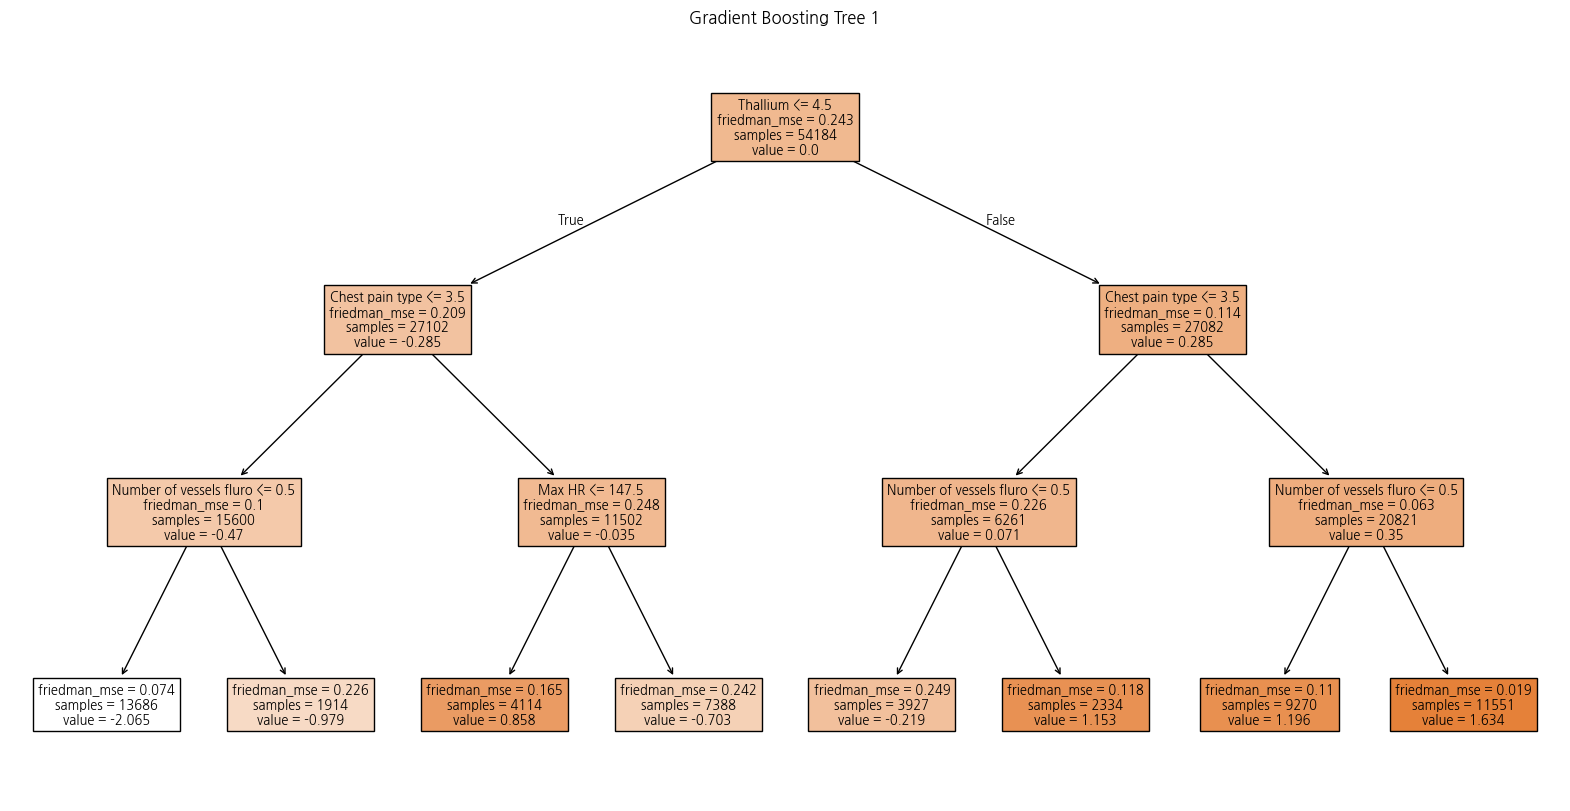

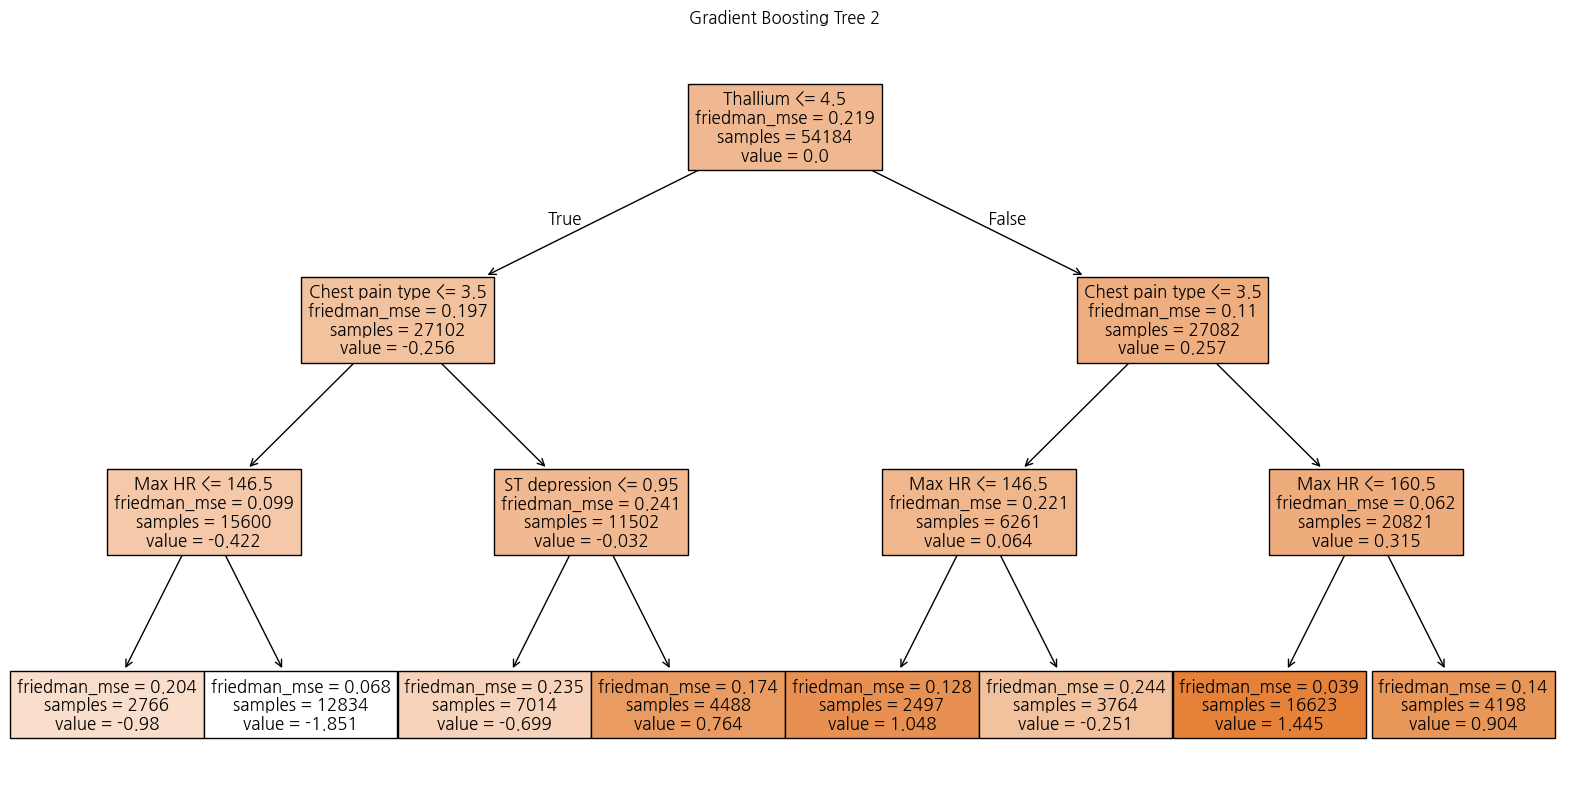

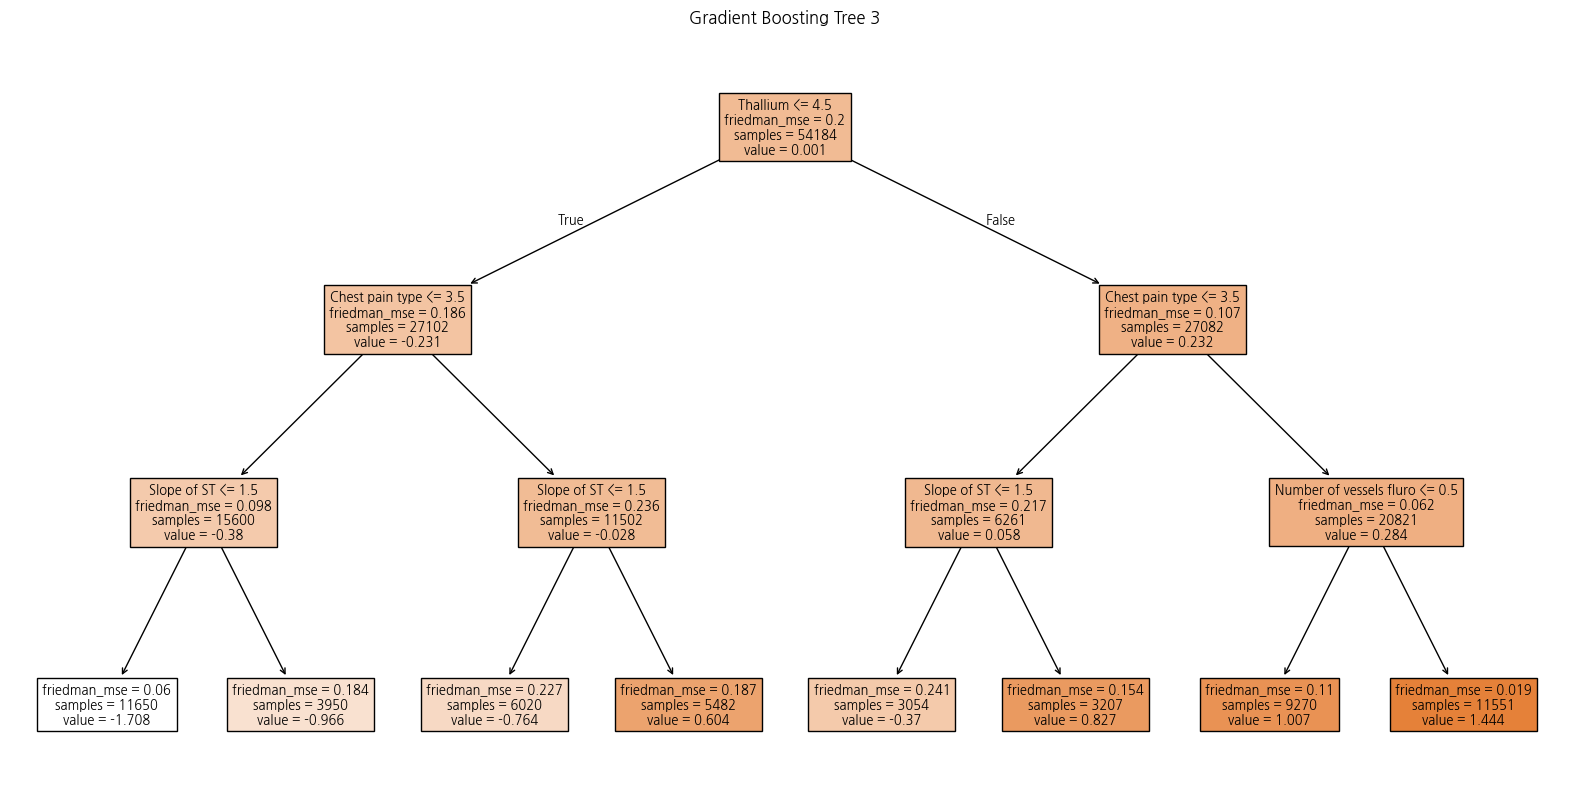

In [146]:
for i in range(3):
    plt.figure(figsize=(20,10))
    plot_tree(
        best_gb.estimators_[i,0],
        feature_names=X_train.columns,
        filled=True
    )
    plt.title(f"Gradient Boosting Tree {i+1}")
    plt.show()

### 모델 성능 비교

In [121]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM'],
    'Accuracy': [dt_acc, model_acc, rf_acc, gb_acc, xgb_acc, lgbm_acc],
    'Precision': [dt_pre, model_pre, rf_pre, gb_pre, xgb_pre, lgbm_pre],
    'Recall': [dt_rec, model_rec, rf_rec, gb_rec, xgb_rec, lgbm_rec],
    'F1 Score': [dt_f1, model_f1, rf_f1, gb_f1, xgb_f1, lgbm_f1],
    'ROC-AUC': [dt_auc, model_auc, rf_auc, gb_auc, xgb_auc, lgbm_auc]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0        Decision Tree  0.809243   0.832853  0.841712  0.837259  0.802782
1  Logistic Regression  0.872066   0.888945  0.891984  0.890462  0.802782
2        Random Forest  0.869703   0.882867  0.895277  0.889029  0.938575
3    Gradient Boosting  0.875388   0.889768  0.897429  0.893582  0.946714
4              XGBoost  0.874206   0.889644  0.895277  0.892451  0.946130
5             LightGBM  0.874502   0.889308  0.896290  0.892785  0.946029


### 정확도 비교 그래프

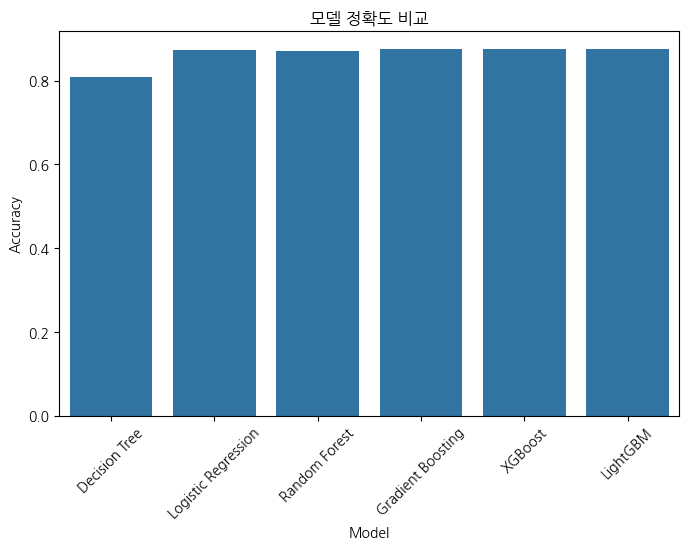

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='Accuracy', data=results)

plt.title("모델 정확도 비교")
plt.xticks(rotation=45)

plt.show()

### 여러 성능 지표 비교 그래프

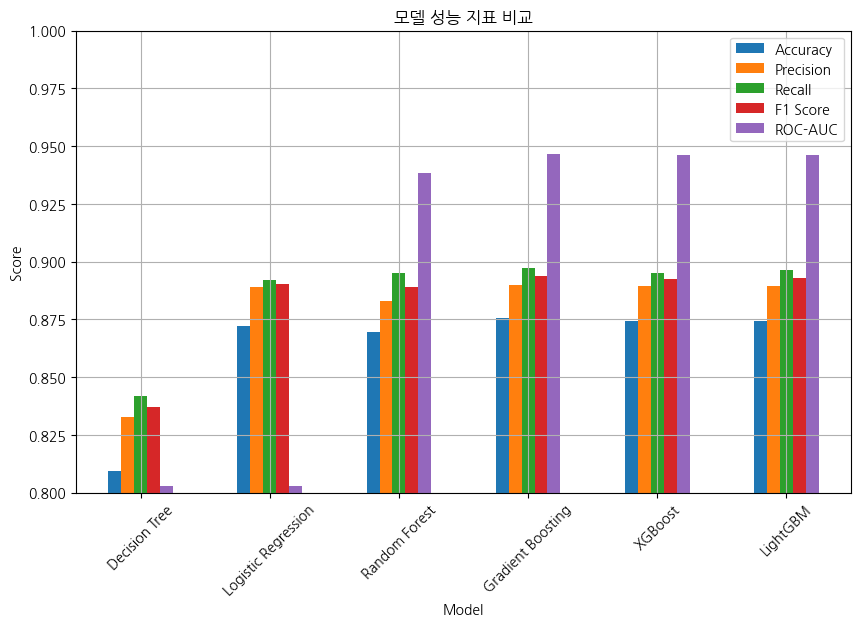

In [138]:
results.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("모델 성능 지표 비교")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.ylim(0.8, 1.0)
plt.grid('y')

plt.show()

### ROC Curve 비교

In [124]:
dt_prob = dt_clf.predict_proba(X_test)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]
gb_prob = gb_model.predict_proba(X_test)[:,1]
xgb_prob = xgb_model.predict_proba(X_test)[:,1]
lgbm_prob = lgbm_model.predict_proba(X_test)[:,1]
lr_prob = model.predict_proba(X_test_scaled)[:,1]

c:\Users\KDS21\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


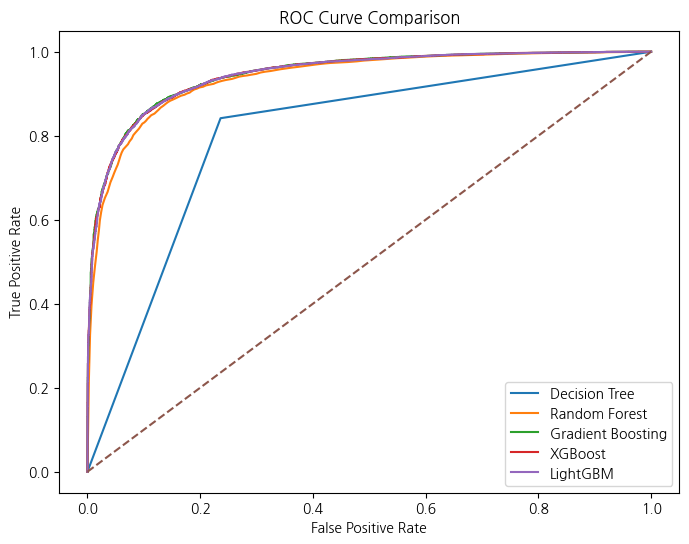

In [125]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

fpr, tpr, _ = roc_curve(y_test, dt_prob)
plt.plot(fpr, tpr, label="Decision Tree")

fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label="Random Forest")

fpr, tpr, _ = roc_curve(y_test, gb_prob)
plt.plot(fpr, tpr, label="Gradient Boosting")

fpr, tpr, _ = roc_curve(y_test, xgb_prob)
plt.plot(fpr, tpr, label="XGBoost")

fpr, tpr, _ = roc_curve(y_test, lgbm_prob)
plt.plot(fpr, tpr, label="LightGBM")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

### F1 - Score 비교 그래프

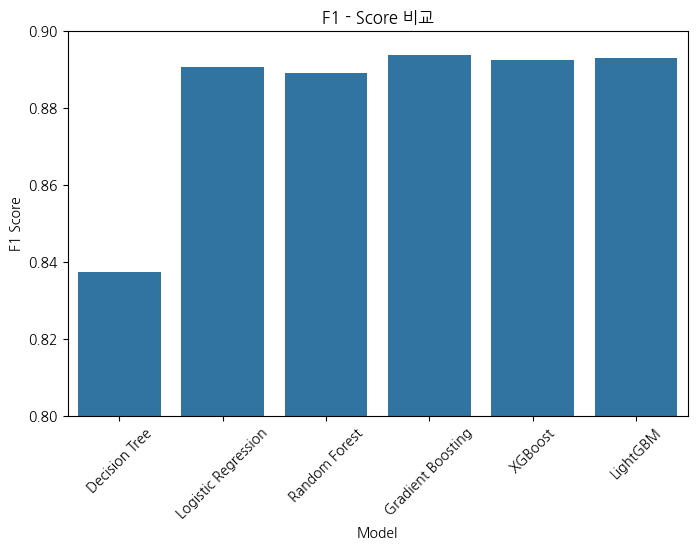

In [140]:
plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='F1 Score', data=results)

plt.title("F1 - Score 비교")
plt.xticks(rotation=45)

plt.ylim(0.8, 0.9)

plt.show()

### ROC - AUC 비교 그래프

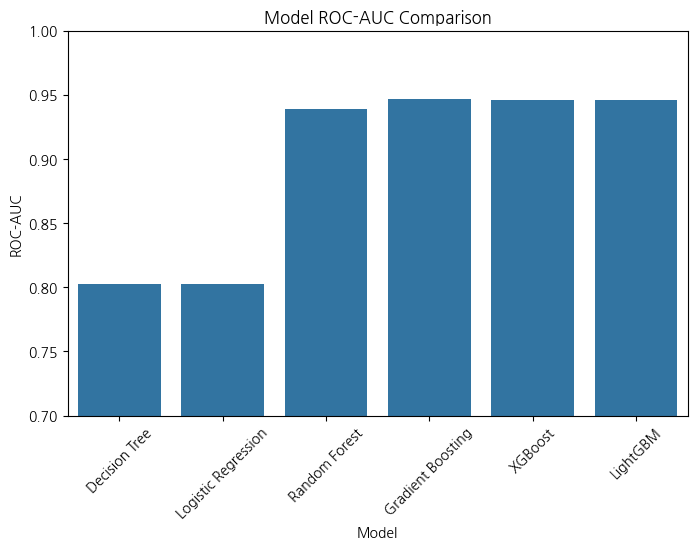

In [143]:
plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='ROC-AUC', data=results)

plt.title("Model ROC-AUC Comparison")
plt.xticks(rotation=45)

plt.ylim(0.7, 1.0)

plt.show()

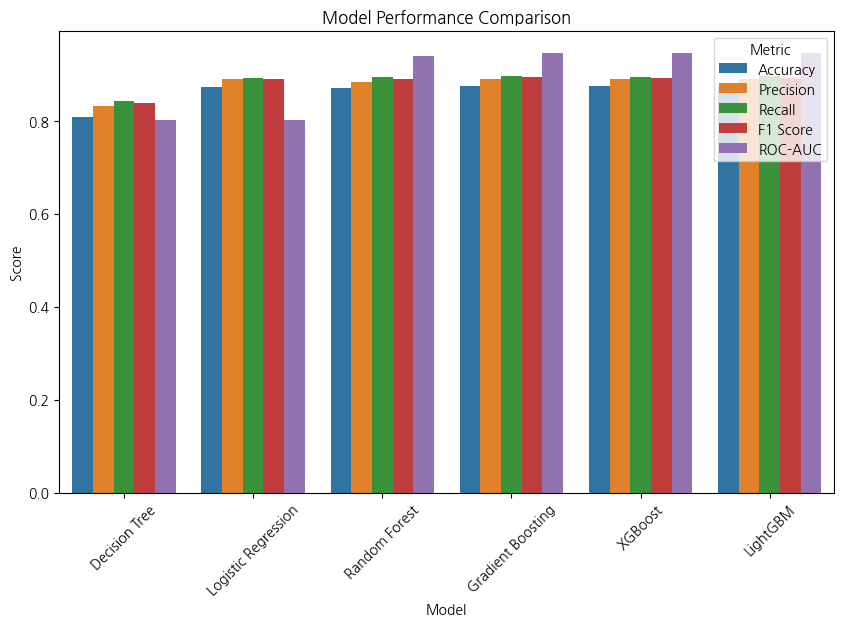

In [128]:
results_melt = results.melt(id_vars='Model',
                            var_name='Metric',
                            value_name='Score')

plt.figure(figsize=(10,6))

sns.barplot(x='Model', y='Score', hue='Metric', data=results_melt)

plt.title("Model Performance Comparison")
plt.xticks(rotation=45)

plt.show()

### 예측 모델

In [129]:
# 전체 모델 학습
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X, y)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [130]:
# 모델이 기대하는 컬럼 이름들을 직접 출력해서 확인합니다.
print("모델이 원하는 컬럼들:", gb_model.feature_names_in_)

모델이 원하는 컬럼들: ['Age' 'Sex' 'Chest pain type' 'BP' 'Cholesterol' 'FBS over 120'
 'EKG results' 'Max HR' 'Exercise angina' 'ST depression' 'Slope of ST'
 'Number of vessels fluro' 'Thallium' 'old']


In [131]:
import pandas as pd

# [Age, Sex, Chest pain type, BP, Cholesterol, FBS over 120, EKG results, 
#  Max HR, Exercise angina, ST depression, Slope of ST, Number of vessels fluro, Thallium, old]
data = [
    [62, 1, 4, 145, 280, 1, 0, 130, 1, 2.5, 2, 2, 7, False], # 가상 환자 A
    [45, 0, 2, 120, 210, 0, 1, 165, 0, 0.0, 1, 0, 3, False]  # 가상 환자 B
]

cols = ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 
        'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 
        'Slope of ST', 'Number of vessels fluro', 'Thallium', 'old']

new_data = pd.DataFrame(data, columns=cols)

prediction = gb_model.predict(new_data)

print("예측 결과 (0: 정상, 1: 질환):", prediction)

prob = gb_model.predict_proba(new_data)
print("질환일 확률:", prob[:, 1])

예측 결과 (0: 정상, 1: 질환): [1 0]
질환일 확률: [0.99487627 0.02283392]


### 히트맵

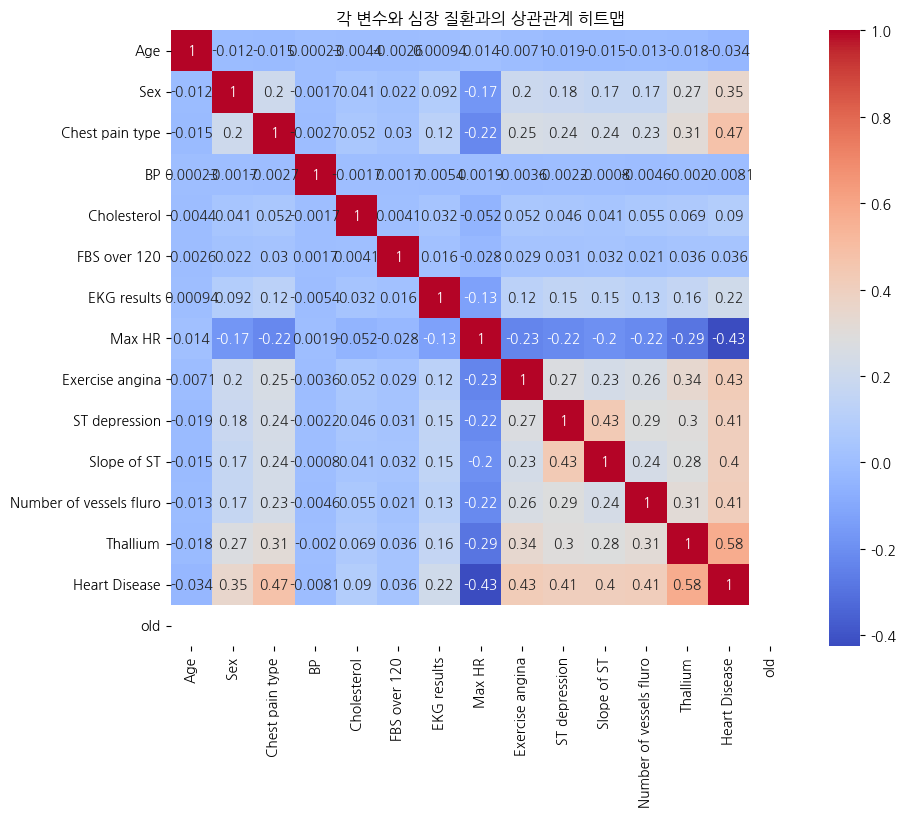

In [132]:
plt.figure(figsize=(10,8))

corr = df_old.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("각 변수와 심장 질환과의 상관관계 히트맵")

plt.show()

### 탈륨과 심장 질환 간의 관계 산점도

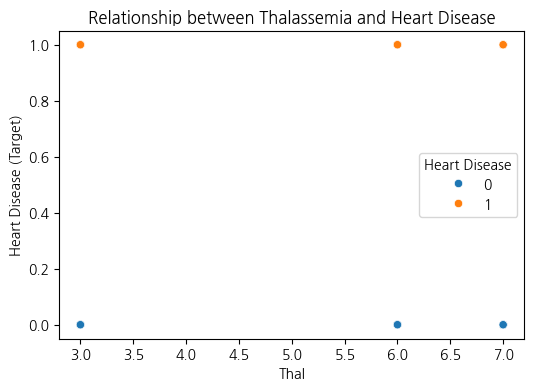

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.scatterplot(x='Thallium', y='Heart Disease', data=df_old, hue='Heart Disease')

plt.title("Relationship between Thalassemia and Heart Disease")
plt.xlabel("Thal")
plt.ylabel("Heart Disease (Target)")

plt.show()

### 탈륨과 심장 질환 간의 관계 Count Plot

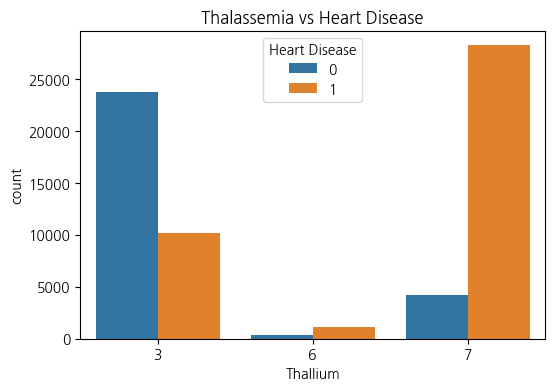

In [134]:
plt.figure(figsize=(6,4))

sns.countplot(x='Thallium', hue='Heart Disease', data=df_old)

plt.title("Thalassemia vs Heart Disease")

plt.show()